# Model 2 — 1D-CNN (Member: Bhavya)

Human Activity Recognition from raw smartphone inertial signals (UCI HAR).

This notebook trains and evaluates the **1D Convolutional Neural Network**: three stacked Conv1D blocks (64, 128, 128 filters) each with batch normalisation, ReLU and max pooling, followed by global average pooling and a dense classification head. The convolutional structure imposes translation invariance and locality, so the network can pick up a short repeating motion motif (e.g. one phase of a gait cycle) anywhere in the 2.56s window.

Uses the **shared** `src/har_data.py` pipeline (subject-independent split, per-channel standardisation) and the **shared** `src/train.py` / `src/evaluate.py` harness, so this model is trained and scored on byte-identical data and metrics as the MLP and BiLSTM.

In [1]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import torch

from har_data import set_seed, load_bundle, make_loaders
from models.cnn1d import HARCnn1D
from train import train_model
from evaluate import evaluate_model, count_parameters, plot_confusion_matrix

DATA_ROOT = PROJECT_ROOT / "data" / "UCI HAR Dataset"
RESULTS_METRICS = PROJECT_ROOT / "results" / "metrics"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"
RESULTS_METRICS.mkdir(parents=True, exist_ok=True)
RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)

SEED = 42
set_seed(SEED)

## 1. Load data under the shared protocol

Subject-independent split: validation subjects are held out from the 21 training subjects (fixed IDs, shared across all three models). Standardisation is fitted on the training subjects only.

In [2]:
bundle = load_bundle(DATA_ROOT)
class_names = bundle["class_names"]

# channels_first=True -> (N, 9, 128), what nn.Conv1d expects
train_loader, val_loader, test_loader = make_loaders(bundle, batch_size=128, channels_first=True)

print(f"classes: {class_names}")
print(f"val subjects held out: {bundle['val_subjects']}")

  train : (5989, 128, 9)  subjects=17
  val   : (1363, 128, 9)  subjects=[8, 16, 23, 29]
  test  : (2947, 128, 9)  subjects=9
  train class balance:
    WALKING               1015  (16.9%)
    WALKING_UPSTAIRS       881  (14.7%)
    WALKING_DOWNSTAIRS     799  (13.3%)
    SITTING               1043  (17.4%)
    STANDING              1109  (18.5%)
    LAYING                1142  (19.1%)
classes: ('WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING')
val subjects held out: (8, 16, 23, 29)


## 2. Build the model

In [3]:
model = HARCnn1D(in_channels=bundle["input_shape"][1], n_classes=bundle["n_classes"])
print(model)
print(f"trainable parameters: {count_parameters(model):,}")

HARCnn1D(
  (blocks): Sequential(
    (0): ConvBlock(
      (net): Sequential(
        (0): Conv1d(9, 64, kernel_size=(7,), stride=(1,), padding=(3,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (net): Sequential(
        (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (net): Sequential(
        (0): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=Tr

## 3. Train

Adam + categorical cross-entropy, early-stopped on subject-held-out validation loss — the shared protocol from `src/train.py`.

In [4]:
result = train_model(
    model,
    train_loader,
    val_loader,
    lr=3e-4,
    weight_decay=1e-4,
    max_epochs=100,
    patience=15,
)

print(f"best epoch: {result['best_epoch']}")
print(f"best val loss: {result['best_val_loss']:.4f}")
print(f"training time: {result['training_time_sec']:.1f}s")
print(f"trainable parameters: {result['n_params']:,}")
print(f"device: {result['device']}")

C:\Deep Learning Project\Deep-Learning\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  epoch   1  train_loss=0.6467  val_loss=0.4701  val_acc=0.8672 *


  epoch   2  train_loss=0.2136  val_loss=0.4644  val_acc=0.8518 *


  epoch   3  train_loss=0.1528  val_loss=0.4477  val_acc=0.8511 *


  epoch   4  train_loss=0.1233  val_loss=0.4277  val_acc=0.8503 *


...

  epoch  17  train_loss=0.0625  val_loss=0.5411  val_acc=0.8577


  epoch  18  train_loss=0.0641  val_loss=0.4459  val_acc=0.8716


  epoch  19  train_loss=0.0589  val_loss=0.5448  val_acc=0.8401


  epoch  20  train_loss=0.0670  val_loss=0.4701  val_acc=0.8687


  epoch  21  train_loss=0.0599  val_loss=0.4889  val_acc=0.8672
  early stopping at epoch 21 (no val_loss improvement for 15 epochs)
best epoch: 6
best val loss: 0.3983
training time: 76.2s
trainable parameters: 128,646
device: cpu


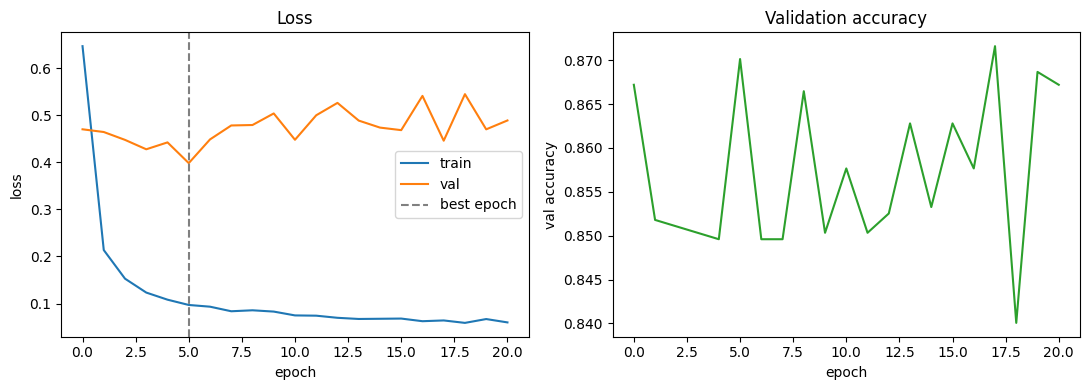

In [5]:
history = result["history"]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="val")
ax[0].axvline(result["best_epoch"] - 1, color="grey", linestyle="--", label="best epoch")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].legend(); ax[0].set_title("Loss")

ax[1].plot(history["val_acc"], color="tab:green")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val accuracy"); ax[1].set_title("Validation accuracy")
fig.tight_layout()
fig.savefig(RESULTS_FIGURES / "cnn1d_training_curves.png", dpi=150)
plt.show()

## 4. Evaluate on the held-out test set (9 subjects, never seen during training or validation)

In [6]:
metrics = evaluate_model(model, test_loader, device=result["device"], class_names=class_names)

print(f"accuracy       : {metrics['accuracy']:.4f}")
print(f"macro precision: {metrics['macro_precision']:.4f}")
print(f"macro recall   : {metrics['macro_recall']:.4f}")
print(f"macro F1       : {metrics['macro_f1']:.4f}")
print()
print(metrics["classification_report"])

accuracy       : 0.9298
macro precision: 0.9301
macro recall   : 0.9308
macro F1       : 0.9296

                    precision    recall  f1-score   support

           WALKING       1.00      0.98      0.99       496
  WALKING_UPSTAIRS       0.98      0.90      0.94       471
WALKING_DOWNSTAIRS       0.89      1.00      0.94       420
           SITTING       0.86      0.83      0.84       491
          STANDING       0.86      0.87      0.87       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



In [7]:
plot_confusion_matrix(
    metrics["confusion_matrix"],
    class_names,
    save_path=RESULTS_FIGURES / "cnn1d_confusion_matrix.png",
    title="1D-CNN — normalised confusion matrix (test set)",
)
print(f"saved to {RESULTS_FIGURES / 'cnn1d_confusion_matrix.png'}")

saved to C:\Deep Learning Project\Deep-Learning\results\figures\cnn1d_confusion_matrix.png


## 5. Save metrics for the comparison table

Written to `results/metrics/cnn1d_metrics.json` so `Model 1` and `Model 3` results can be merged into the single cross-model comparison table required by the report.

In [8]:
summary = {
    "model": "1D-CNN",
    "owner": "Bhavya",
    "seed": SEED,
    "val_subjects": list(bundle["val_subjects"]),
    "n_params": result["n_params"],
    "training_time_sec": result["training_time_sec"],
    "best_epoch": result["best_epoch"],
    "best_val_loss": result["best_val_loss"],
    "test_accuracy": metrics["accuracy"],
    "test_macro_precision": metrics["macro_precision"],
    "test_macro_recall": metrics["macro_recall"],
    "test_macro_f1": metrics["macro_f1"],
    "per_class_f1": metrics["per_class_f1"],
    "confusion_matrix": metrics["confusion_matrix"],
}

out_path = RESULTS_METRICS / "cnn1d_metrics.json"
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"saved to {out_path}")
summary

saved to C:\Deep Learning Project\Deep-Learning\results\metrics\cnn1d_metrics.json


{'model': '1D-CNN',
 'owner': 'Bhavya',
 'seed': 42,
 'val_subjects': [8, 16, 23, 29],
 'n_params': 128646,
 'training_time_sec': 76.15121630000067,
 'best_epoch': 6,
 'best_val_loss': 0.3982793498669511,
 'test_accuracy': 0.9297590770274856,
 'test_macro_precision': 0.9301215238709114,
 'test_macro_recall': 0.9307805083711237,
 'test_macro_f1': 0.9295635989056371,
 'per_class_f1': {'WALKING': 0.9898580121703854,
  'WALKING_UPSTAIRS': 0.9380530973451328,
  'WALKING_DOWNSTAIRS': 0.9384098544232923,
  'SITTING': 0.8435233160621761,
  'STANDING': 0.8675373134328358,
  'LAYING': 1.0},
 'confusion_matrix': [[488, 0, 8, 0, 0, 0],
  [1, 424, 46, 0, 0, 0],
  [1, 0, 419, 0, 0, 0],
  [0, 9, 0, 407, 75, 0],
  [0, 0, 0, 67, 465, 0],
  [0, 0, 0, 0, 0, 537]]}

## 6. Notes / error analysis (fill in after running)

- Which classes does the confusion matrix show being confused? Does the sitting/standing confusion the synopsis predicts show up here?
- How does the parameter count and training time compare to Model 1 (MLP) once that's run?
- Anything about the convolutional inductive bias (local motion motifs, translation invariance) that shows up in *this* model's specific error pattern, as distinct from Model 1's or Model 3's?